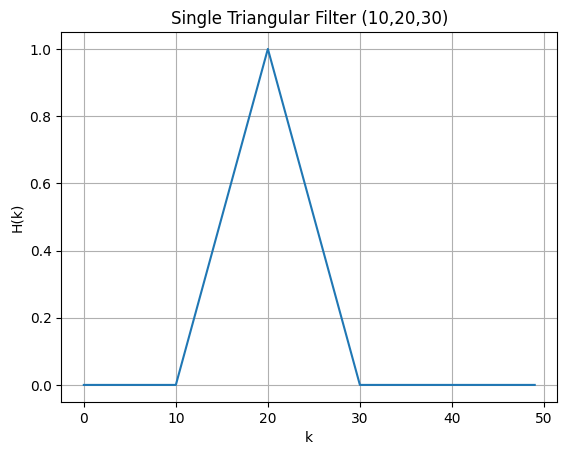

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define triangle points
a, b, c = 10, 20, 30

# Create k axis
k = np.arange(0, 50)

# Triangular filter
H = np.zeros_like(k, dtype=float)

for i in range(len(k)):
    if a <= k[i] <= b:
        H[i] = (k[i] - a) / (b - a)
    elif b <= k[i] <= c:
        H[i] = (c - k[i]) / (c - b)

# Plot
plt.plot(k, H)
plt.title("Single Triangular Filter (10,20,30)")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.grid()
plt.show()

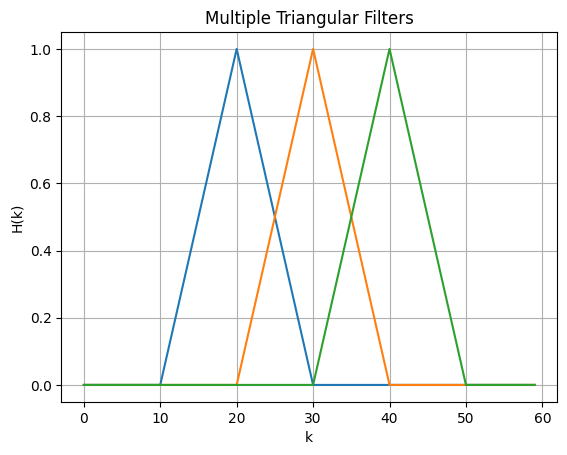

In [2]:
import numpy as np
import matplotlib.pyplot as plt

triangles = [(10,20,30), (20,30,40), (30,40,50)]

k = np.arange(0, 60)

plt.figure()

for (a,b,c) in triangles:
    H = np.zeros_like(k, dtype=float)

    for i in range(len(k)):
        if a <= k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif b <= k[i] <= c:
            H[i] = (c - k[i]) / (c - b)

    plt.plot(k, H)

plt.title("Multiple Triangular Filters")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.grid()
plt.show()

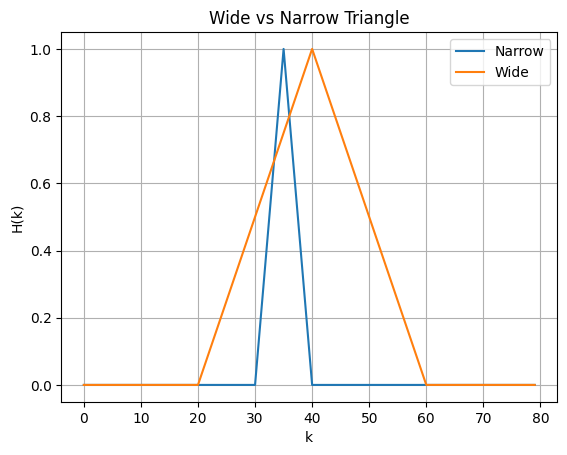

In [3]:
import numpy as np
import matplotlib.pyplot as plt

k = np.arange(0, 80)

# Narrow triangle
a1, b1, c1 = 30, 35, 40

# Wide triangle
a2, b2, c2 = 20, 40, 60

def triangle(a,b,c,k):
    H = np.zeros_like(k, dtype=float)
    for i in range(len(k)):
        if a <= k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif b <= k[i] <= c:
            H[i] = (c - k[i]) / (c - b)
    return H

plt.plot(k, triangle(a1,b1,c1,k), label="Narrow")
plt.plot(k, triangle(a2,b2,c2,k), label="Wide")

plt.title("Wide vs Narrow Triangle")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()

step 1

In [4]:
fs = 16000       # Sampling frequency
N = 512          # FFT size
M = 20           # Number of filters
fmin = 0
fmax = fs / 2

step 2

In [5]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f/700)

def mel_to_hz(m):
    return 700 * (10**(m/2595) - 1)

mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

step 3

In [6]:
mel_points = np.linspace(mel_min, mel_max, M+2)

step 4

In [7]:
freq_points = mel_to_hz(mel_points)

step 5

In [8]:
bin_points = np.floor((N+1) * freq_points / fs).astype(int)

print("Triangular Filter Points (a,b,c):")
for i in range(1, M+1):
    print(f"Filter {i}: ({bin_points[i-1]}, {bin_points[i]}, {bin_points[i+1]})")

Triangular Filter Points (a,b,c):
Filter 1: (0, 2, 6)
Filter 2: (2, 6, 9)
Filter 3: (6, 9, 13)
Filter 4: (9, 13, 18)
Filter 5: (13, 18, 23)
Filter 6: (18, 23, 29)
Filter 7: (23, 29, 36)
Filter 8: (29, 36, 43)
Filter 9: (36, 43, 52)
Filter 10: (43, 52, 61)
Filter 11: (52, 61, 72)
Filter 12: (61, 72, 84)
Filter 13: (72, 84, 97)
Filter 14: (84, 97, 113)
Filter 15: (97, 113, 130)
Filter 16: (113, 130, 150)
Filter 17: (130, 150, 172)
Filter 18: (150, 172, 196)
Filter 19: (172, 196, 224)
Filter 20: (196, 224, 256)


objective 2 . (i) 

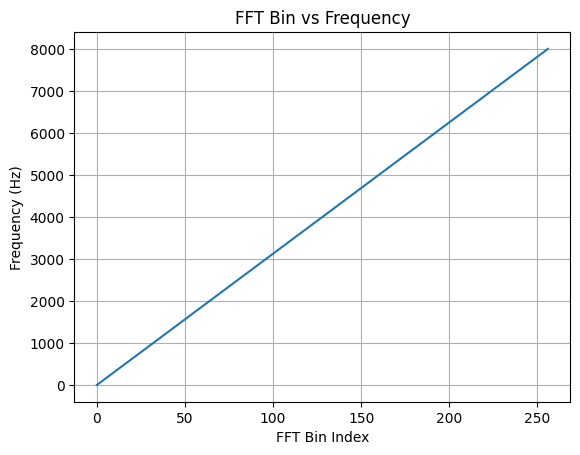

In [9]:
bins = np.arange(0, N//2 + 1)
frequencies = bins * fs / N

plt.plot(bins, frequencies)
plt.title("FFT Bin vs Frequency")
plt.xlabel("FFT Bin Index")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()

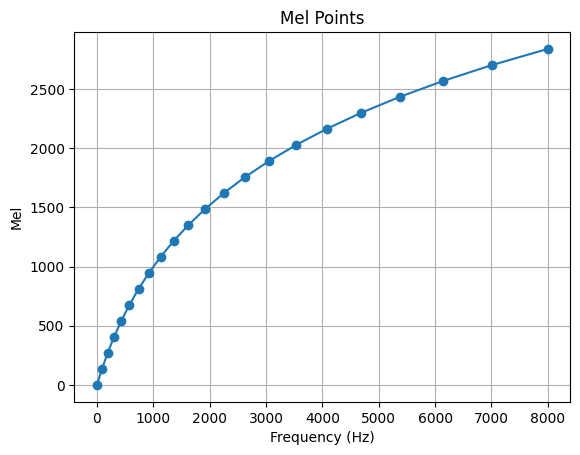

In [10]:
plt.plot(freq_points, mel_points, 'o-')
plt.title("Mel Points")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mel")
plt.grid()
plt.show()

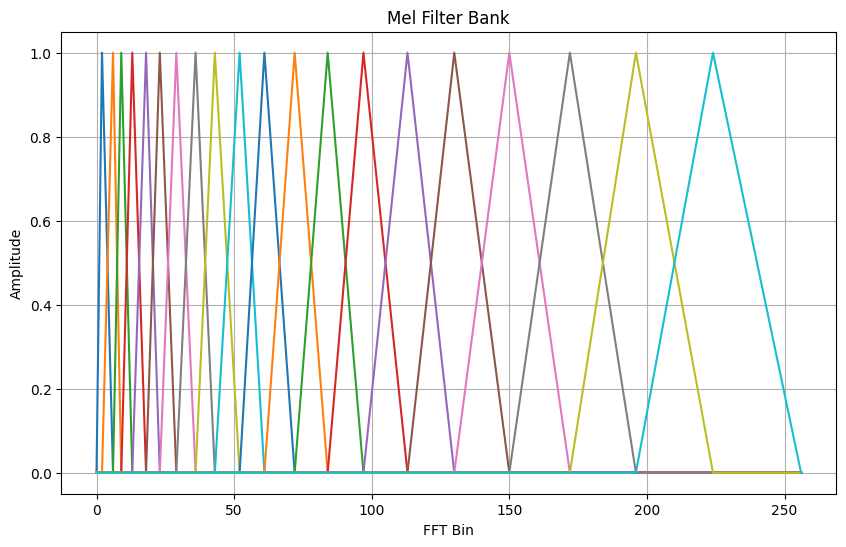

In [11]:
filter_bank = np.zeros((M, N//2 + 1))

for m in range(1, M+1):
    for k in range(bin_points[m-1], bin_points[m]):
        filter_bank[m-1, k] = (k - bin_points[m-1]) / (bin_points[m] - bin_points[m-1])
        
    for k in range(bin_points[m], bin_points[m+1]):
        filter_bank[m-1, k] = (bin_points[m+1] - k) / (bin_points[m+1] - bin_points[m])

# Plot filter bank
plt.figure(figsize=(10,6))
for m in range(M):
    plt.plot(filter_bank[m])

plt.title("Mel Filter Bank")
plt.xlabel("FFT Bin")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


Triangular Filter Points (a, b, c):

Filter 1: (0, 4, 9)
Filter 2: (4, 9, 15)
Filter 3: (9, 15, 22)
Filter 4: (15, 22, 30)
Filter 5: (22, 30, 41)
Filter 6: (30, 41, 53)
Filter 7: (41, 53, 67)
Filter 8: (53, 67, 84)
Filter 9: (67, 84, 104)
Filter 10: (84, 104, 128)


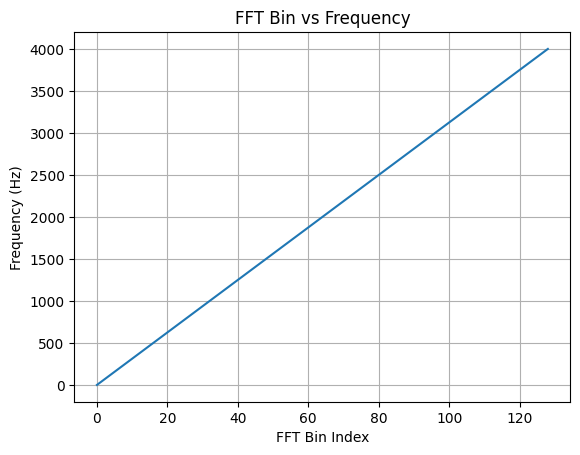

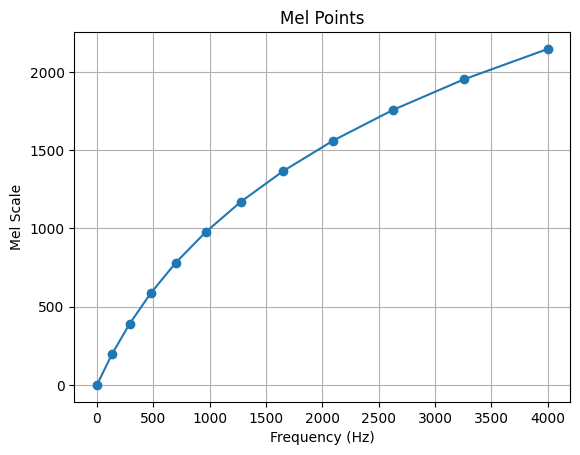

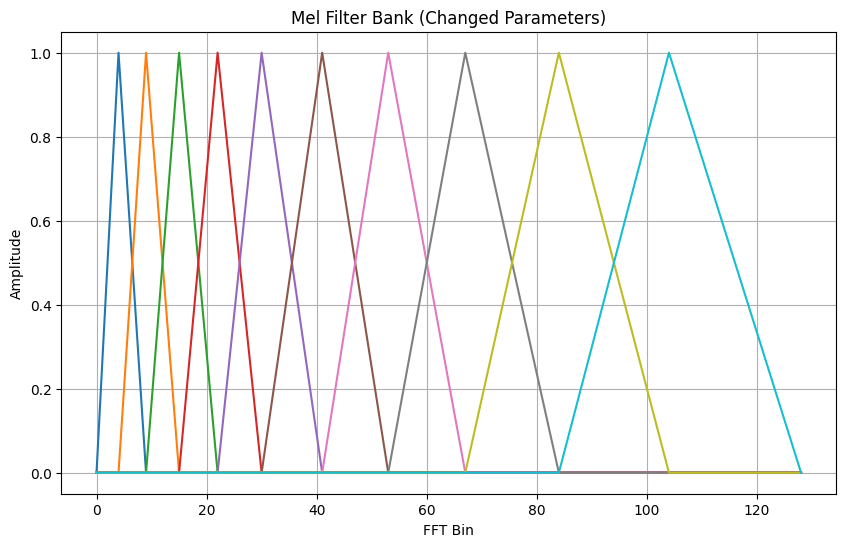

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 🔹 CHANGE PARAMETERS HERE
# ==============================
fs = 8000        # Sampling Frequency (changed)
N = 256          # FFT size (changed)
M = 10           # Number of Mel filters (changed)

fmin = 0
fmax = fs / 2

# ==============================
# 🔹 Step 1: Mel Conversion Functions
# ==============================

def hz_to_mel(f):
    return 2595 * np.log10(1 + f/700)

def mel_to_hz(m):
    return 700 * (10**(m/2595) - 1)

# ==============================
# 🔹 Step 2: Convert Frequency to Mel
# ==============================

mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

# ==============================
# 🔹 Step 3: Generate Mel Points
# ==============================

mel_points = np.linspace(mel_min, mel_max, M + 2)

# ==============================
# 🔹 Step 4: Convert Back to Frequency
# ==============================

freq_points = mel_to_hz(mel_points)

# ==============================
# 🔹 Step 5: Convert to FFT Bins
# ==============================

bin_points = np.floor((N + 1) * freq_points / fs).astype(int)

print("\nTriangular Filter Points (a, b, c):\n")
for i in range(1, M + 1):
    print(f"Filter {i}: ({bin_points[i-1]}, {bin_points[i]}, {bin_points[i+1]})")

# ==============================
# 🔹 Report (i): FFT Bin vs Frequency
# ==============================

bins = np.arange(0, N//2 + 1)
frequencies = bins * fs / N

plt.figure()
plt.plot(bins, frequencies)
plt.title("FFT Bin vs Frequency")
plt.xlabel("FFT Bin Index")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()

# ==============================
# 🔹 Report (ii): Plot Mel Points
# ==============================

plt.figure()
plt.plot(freq_points, mel_points, 'o-')
plt.title("Mel Points")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mel Scale")
plt.grid()
plt.show()

# ==============================
# 🔹 Step 6: Construct Mel Filter Bank
# ==============================

filter_bank = np.zeros((M, N//2 + 1))

for m in range(1, M + 1):
    
    # Rising slope
    for k in range(bin_points[m-1], bin_points[m]):
        filter_bank[m-1, k] = (k - bin_points[m-1]) / (bin_points[m] - bin_points[m-1])
    
    # Falling slope
    for k in range(bin_points[m], bin_points[m+1]):
        filter_bank[m-1, k] = (bin_points[m+1] - k) / (bin_points[m+1] - bin_points[m])

# ==============================
# 🔹 Plot Mel Filter Bank
# ==============================

plt.figure(figsize=(10,6))
for m in range(M):
    plt.plot(filter_bank[m])

plt.title("Mel Filter Bank (Changed Parameters)")
plt.xlabel("FFT Bin")
plt.ylabel("Amplitude")
plt.grid()
plt.show()